In [4]:
# !pip install ncmcm

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model
from ncmcm.bundlenet.utils import prep_data
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser

2024-07-04 15:13:47.153924: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-04 15:13:47.170030: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-04 15:13:47.170054: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-04 15:13:47.180325: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-04 15:13:47.841364: W tensorflow/compiler/tf

## Load Data (excluding behavioural neurons)

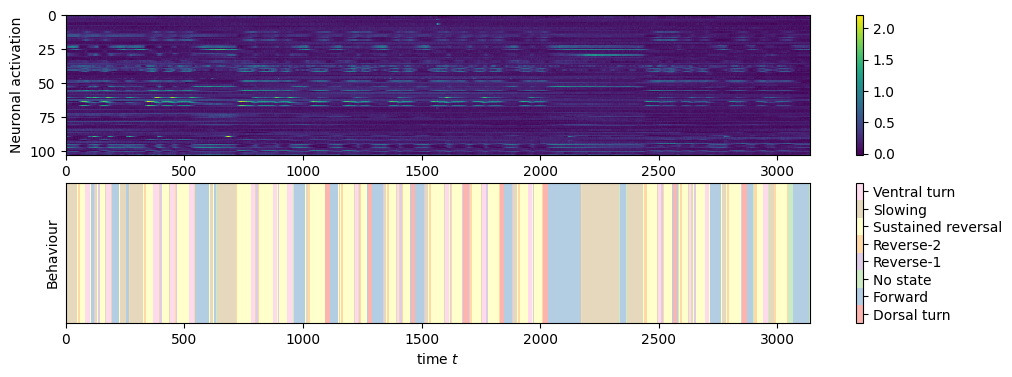

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: xlabel='time $t$', ylabel='Neuronal activation'>,
        <Axes: xlabel='time $t$', ylabel='Behaviour'>], dtype=object))

In [6]:
worm_num = 0
algorithm = 'BunDLe-Net'
b_neurons = [
    'AVAR',
    'AVAL',
    'SMDVR',
    'SMDVL',
    'SMDDR',
    'SMDDL',
    'RIBR',
    'RIBL'
]
data_path = '../datasets/raw/NoStim_Data.mat'
data = Database(data_path=data_path, dataset_no=worm_num)
data.exclude_neurons(b_neurons)
x = data.neuron_traces.T
b = data.behaviour

plotting_neuronal_behavioural(x, b, b_names=data.behaviour_names)

## Preprocess data and embed with BunDLe-Net

In [7]:
# Prepare data for BunDLe Net
x_, b_ = prep_data(x, b, win=15)

# Deploy BunDLe Net
model = BunDLeNet(latent_dim=3, num_behaviour=len(data.behaviour_names))
loss_array, _ = train_model(
    x_,
    b_,
    model,
    b_type='discrete',
    gamma=0.9,
    learning_rate=0.001,
    n_epochs=1000
)

2024-07-04 15:13:49.992265: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:282] failed call to cuInit: CUDA_ERROR_COMPAT_NOT_SUPPORTED_ON_DEVICE: forward compatibility was attempted on non supported HW
2024-07-04 15:13:49.992290: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:134] retrieving CUDA diagnostic information for host: akshey-System-Product-Name
2024-07-04 15:13:49.992295: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:141] hostname: akshey-System-Product-Name
2024-07-04 15:13:49.992368: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:165] libcuda reported version is: 550.90.7
2024-07-04 15:13:49.992385: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:169] kernel reported version is: 550.67.0
2024-07-04 15:13:49.992389: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:251] kernel version 550.67.0 does not match DSO version 550.90.7 -- cannot find working devices in this co

Loss [Markov, Behaviour, Total]: [0.0098 0.0775 0.0873]:   6%|▎    | 60/1000 [00:08<01:37,  9.65it/s]2024-07-04 15:13:58.216253: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0095 0.0776 0.0871]:   6%|▎    | 61/1000 [00:08<01:36,  9.72it/s]2024-07-04 15:13:58.324793: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0085 0.0825 0.091 ]:   6%|▎    | 62/1000 [00:08<01:38,  9.56it/s]2024-07-04 15:13:58.429341: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0085 0.0807 0.0892]:   6%|▎    | 63/1000 [00:08<01:38,  9.56it/s]2024-07-04 15:13:58.545449: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: 

Loss [Markov, Behaviour, Total]: [0.0064 0.0671 0.0735]:  12%|▍   | 124/1000 [00:14<01:28,  9.86it/s]2024-07-04 15:14:04.962724: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.008  0.0651 0.0731]:  12%|▌   | 125/1000 [00:14<01:28,  9.87it/s]2024-07-04 15:14:05.063280: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0073 0.0668 0.0741]:  13%|▌   | 126/1000 [00:14<01:28,  9.88it/s]2024-07-04 15:14:05.164896: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0077 0.0632 0.0709]:  13%|▌   | 127/1000 [00:15<01:28,  9.87it/s]2024-07-04 15:14:05.297663: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: 

Loss [Markov, Behaviour, Total]: [0.0072 0.0585 0.0657]:  19%|▊   | 188/1000 [00:22<01:33,  8.70it/s]2024-07-04 15:14:12.844174: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.007  0.0525 0.0595]:  19%|▊   | 189/1000 [00:22<01:31,  8.90it/s]2024-07-04 15:14:12.954297: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.008  0.0485 0.0565]:  19%|▊   | 190/1000 [00:22<01:30,  8.94it/s]2024-07-04 15:14:13.083306: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0079 0.0505 0.0584]:  19%|▊   | 191/1000 [00:23<01:34,  8.55it/s]2024-07-04 15:14:13.212152: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: 

Loss [Markov, Behaviour, Total]: [0.0072 0.0442 0.0514]:  25%|█   | 252/1000 [00:29<01:16,  9.77it/s]2024-07-04 15:14:19.937438: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0077 0.0436 0.0512]:  25%|█   | 253/1000 [00:29<01:17,  9.69it/s]2024-07-04 15:14:20.042175: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0074 0.0428 0.0502]:  25%|█   | 254/1000 [00:29<01:17,  9.63it/s]2024-07-04 15:14:20.147829: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0077 0.0434 0.0511]:  26%|█   | 255/1000 [00:30<01:17,  9.58it/s]2024-07-04 15:14:20.249052: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: 

...

Loss [Markov, Behaviour, Total]: [0.0056 0.013  0.0186]:  70%|██▊ | 700/1000 [01:18<00:30,  9.71it/s]2024-07-04 15:15:08.892674: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0053 0.0167 0.0219]:  70%|██▊ | 701/1000 [01:18<00:30,  9.65it/s]2024-07-04 15:15:08.991541: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0053 0.0161 0.0214]:  70%|██▊ | 701/1000 [01:18<00:30,  9.65it/s]2024-07-04 15:15:09.096410: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0054 0.015  0.0204]:  70%|██▊ | 703/1000 [01:19<00:30,  9.73it/s]2024-07-04 15:15:09.200000: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: 

Loss [Markov, Behaviour, Total]: [0.0046 0.0138 0.0184]:  76%|███ | 764/1000 [01:25<00:24,  9.67it/s]2024-07-04 15:15:15.509353: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0044 0.0146 0.0191]:  76%|███ | 765/1000 [01:25<00:24,  9.73it/s]2024-07-04 15:15:15.609649: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0046 0.0123 0.0169]:  77%|███ | 766/1000 [01:25<00:23,  9.80it/s]2024-07-04 15:15:15.711881: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0046 0.0114 0.0161]:  77%|███ | 767/1000 [01:25<00:23,  9.78it/s]2024-07-04 15:15:15.813764: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: 

Loss [Markov, Behaviour, Total]: [0.004  0.0096 0.0136]:  83%|███▎| 828/1000 [01:33<00:19,  8.84it/s]2024-07-04 15:15:23.175444: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0039 0.0096 0.0135]:  83%|███▎| 829/1000 [01:33<00:19,  8.89it/s]2024-07-04 15:15:23.288314: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.004  0.0089 0.0129]:  83%|███▎| 830/1000 [01:33<00:19,  8.88it/s]2024-07-04 15:15:23.403173: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0041 0.0092 0.0133]:  83%|███▎| 831/1000 [01:33<00:19,  8.83it/s]2024-07-04 15:15:23.516084: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: 

Loss [Markov, Behaviour, Total]: [0.004  0.0067 0.0106]:  89%|███▌| 892/1000 [01:40<00:12,  8.81it/s]2024-07-04 15:15:30.411544: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0041 0.007  0.0111]:  89%|███▌| 893/1000 [01:40<00:12,  8.68it/s]2024-07-04 15:15:30.527155: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0038 0.0068 0.0106]:  89%|███▌| 894/1000 [01:40<00:12,  8.67it/s]2024-07-04 15:15:30.643499: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0039 0.006  0.0099]:  90%|███▌| 895/1000 [01:40<00:12,  8.65it/s]2024-07-04 15:15:30.757257: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: 

Loss [Markov, Behaviour, Total]: [0.0039 0.0094 0.0133]:  96%|███▊| 956/1000 [01:47<00:05,  8.79it/s]2024-07-04 15:15:37.677687: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0045 0.0093 0.0138]:  96%|███▊| 957/1000 [01:47<00:04,  8.81it/s]2024-07-04 15:15:37.791052: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0041 0.0138 0.0179]:  96%|███▊| 958/1000 [01:47<00:04,  8.83it/s]2024-07-04 15:15:37.908787: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loss [Markov, Behaviour, Total]: [0.0043 0.0151 0.0194]:  96%|███▊| 959/1000 [01:47<00:04,  8.72it/s]2024-07-04 15:15:38.024013: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: 

## Training loss versus epochs

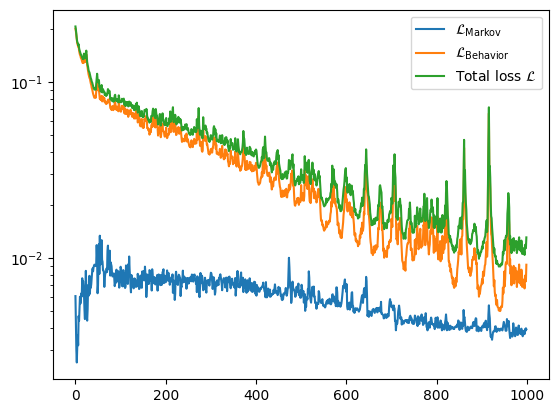

In [18]:
for i, label in enumerate([
    r"$\mathcal{L}_{\mathrm{Markov}}$",
    r"$\mathcal{L}_{\mathrm{Behavior}}$",
    r"Total loss $\mathcal{L}$"
]):
    plt.semilogy(loss_array[:, i], label=label)
plt.legend()
plt.show()

## Projecting into latent space

In [9]:
y0_ = model.tau(x_[:, 0]).numpy()

## Visualising embedding

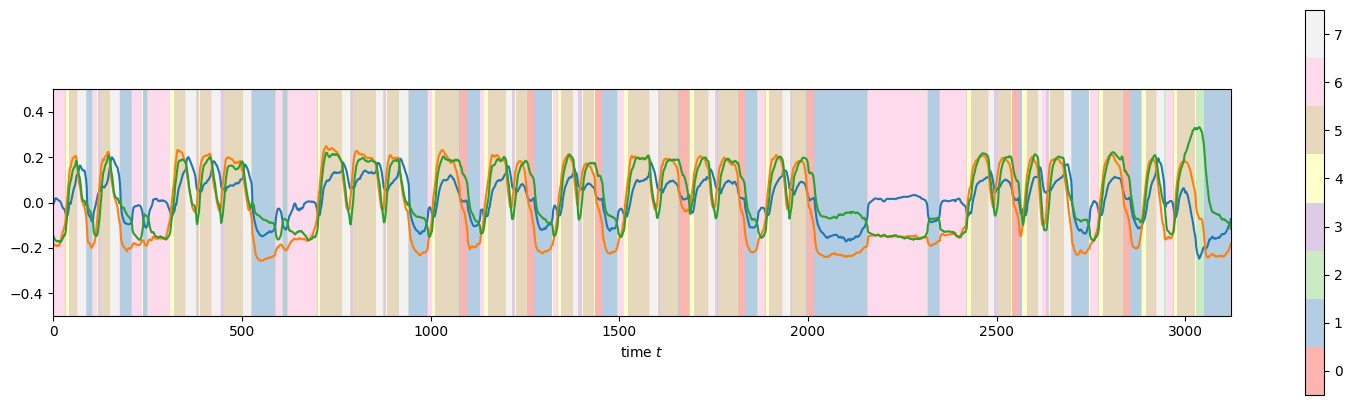

In [10]:
# Plotting latent space dynamics
vis = LatentSpaceVisualiser(y0_, b_, data.behaviour_names)
vis.plot_latent_timeseries()

<IPython.core.display.Javascript object>


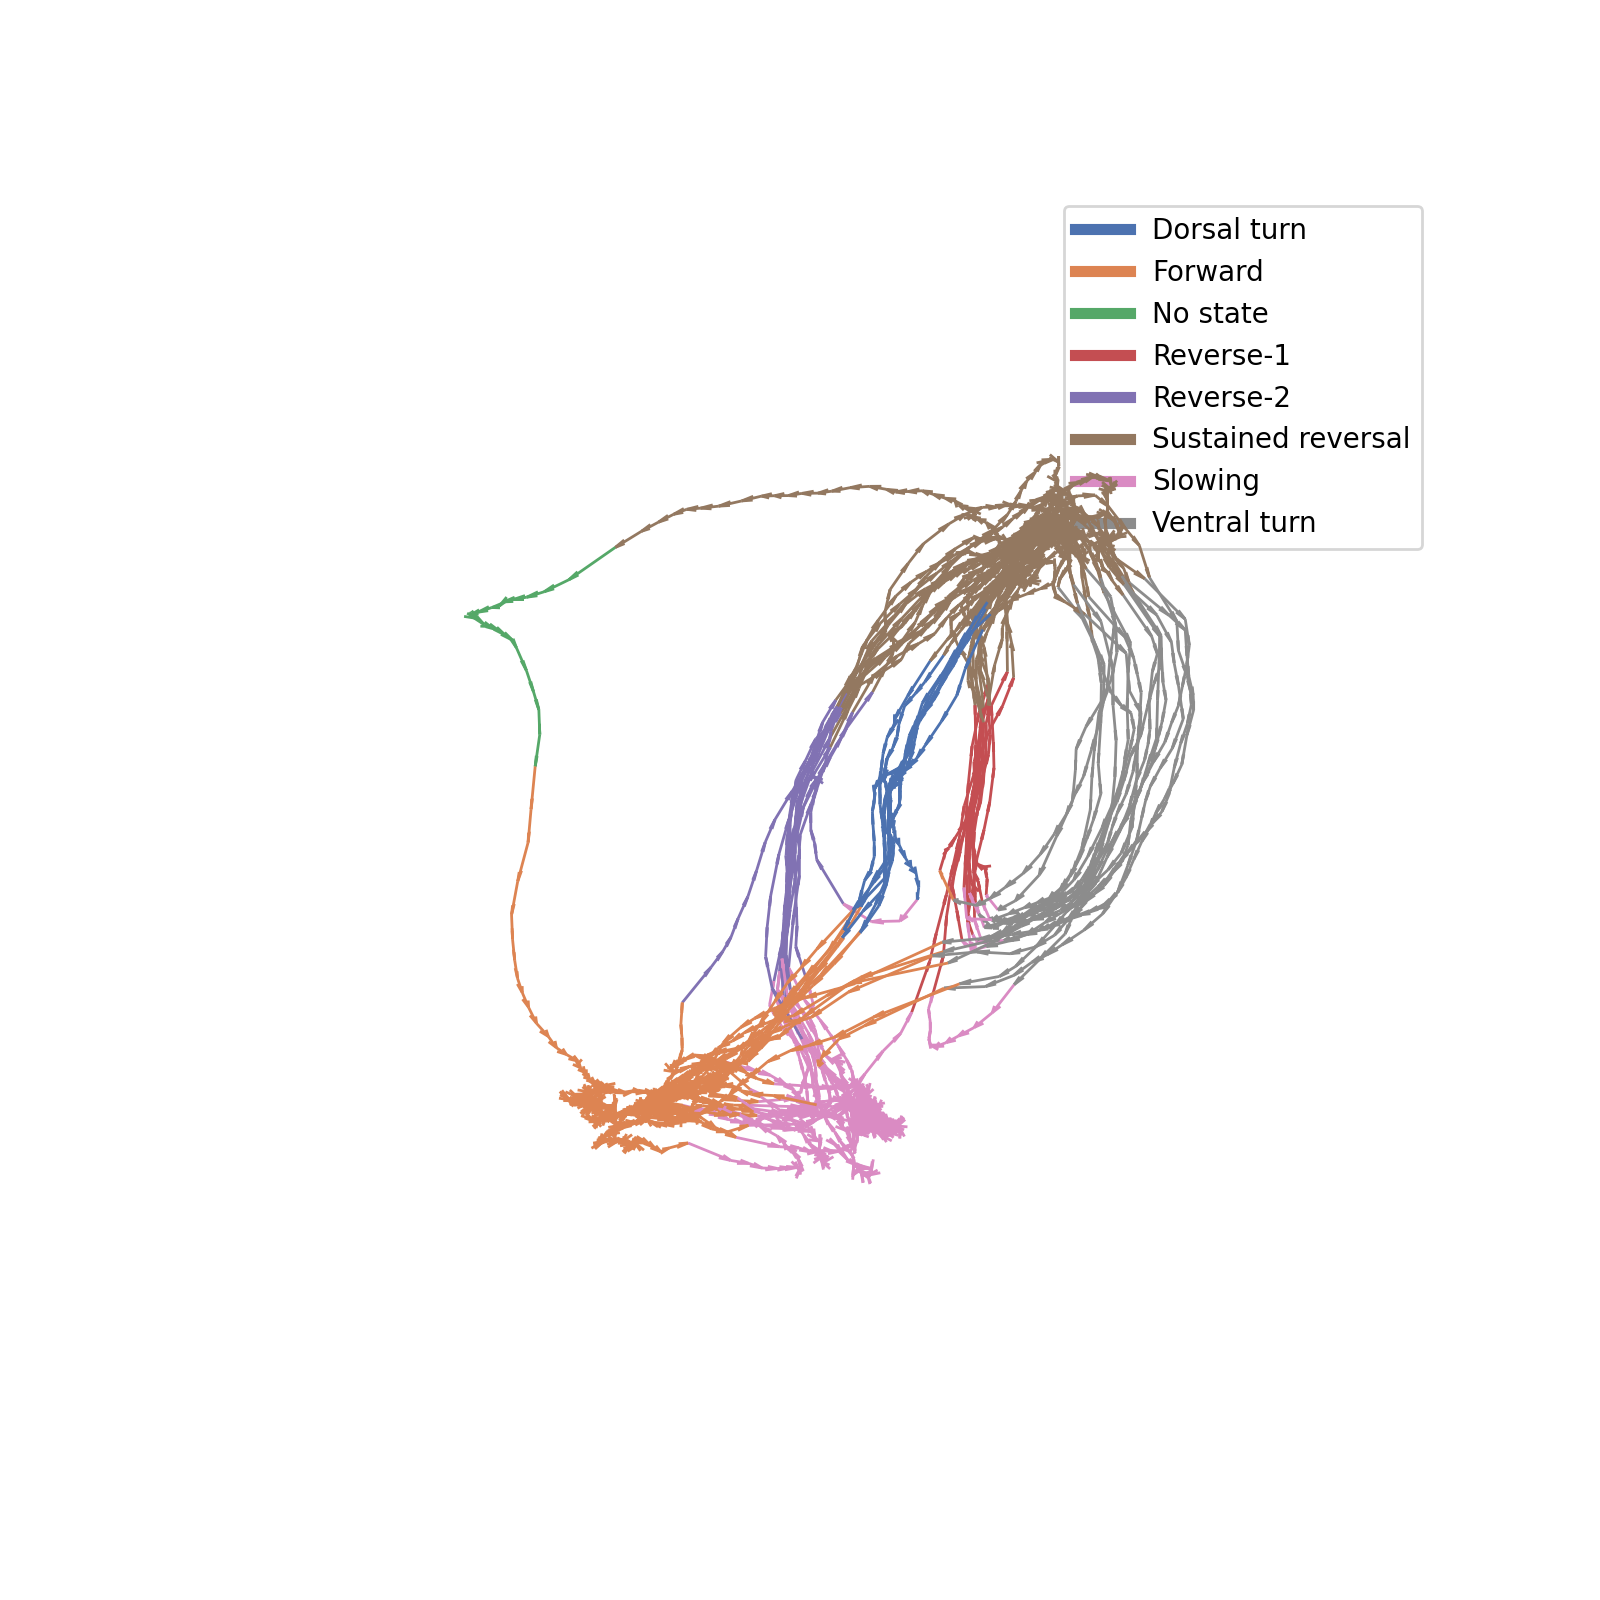

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [14]:
%matplotlib notebook
vis.plot_phase_space()

<IPython.core.display.Javascript object>


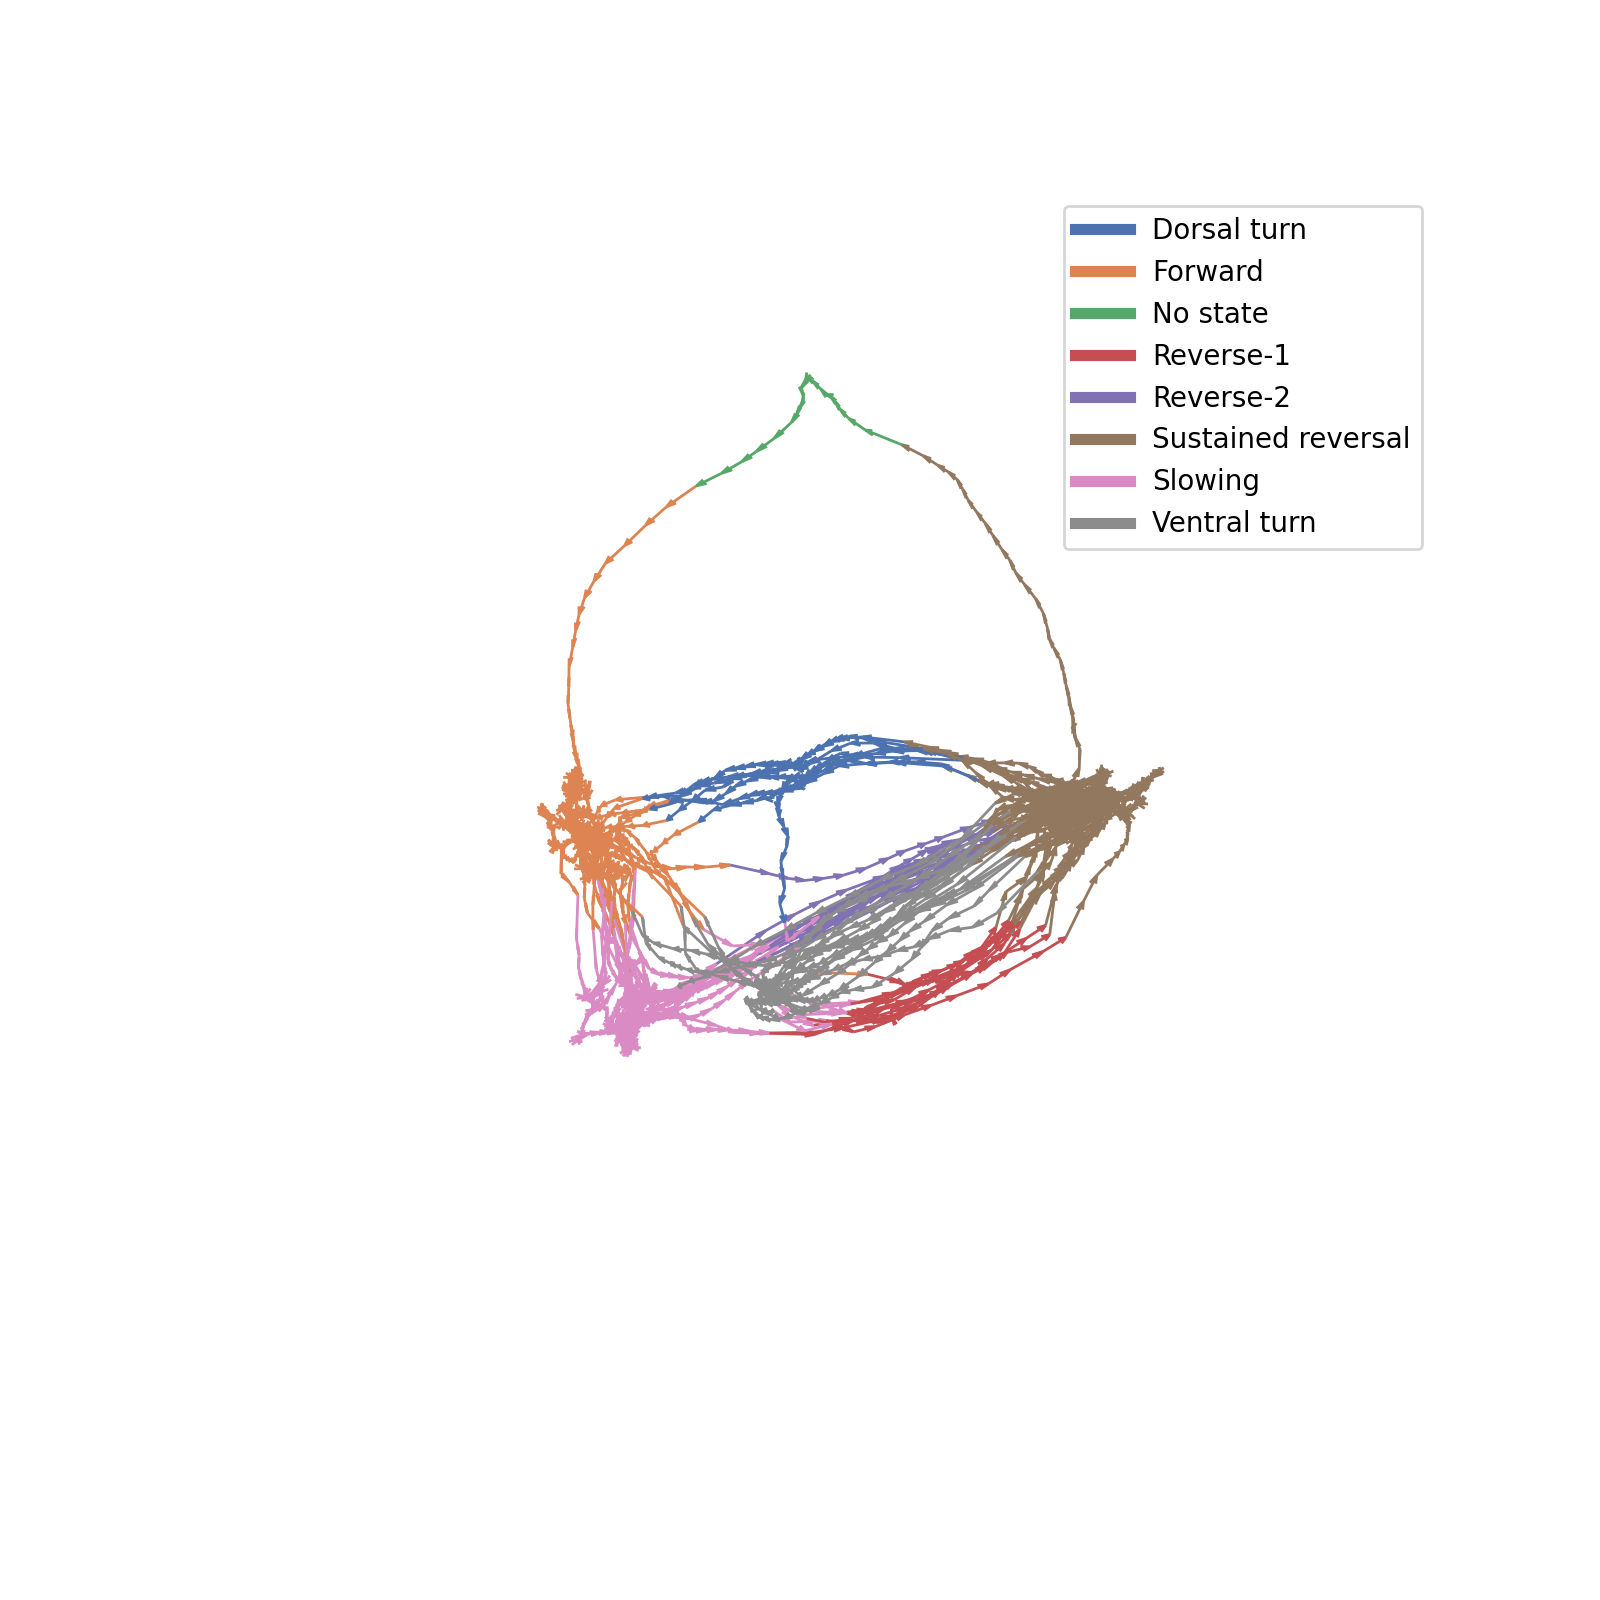

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [15]:
### Run to produce rotating 3-D plot
%matplotlib notebook
vis.rotating_plot(filename='figures/rotation_' + algorithm + '_worm_' + str(worm_num) + '.gif')

### Recurrence plot analysis of BunDLeNet's embedding

<Figure size 640x480 with 0 Axes>

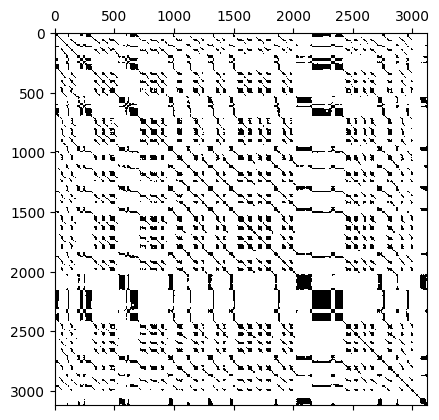

In [17]:
%matplotlib inline
pd_y = np.linalg.norm(y0_[:, np.newaxis] - y0_, axis=-1) < 0.8
plt.figure()
plt.matshow(pd_y, cmap='Greys')
plt.show()